# ML-Based IDS Experiment for Developer Trust Study

This notebook supports the thesis design:

- Dataset: UNSW-NB15
- Models: Logistic Regression and Random Forest
- Goal: Use the ML model as an experimental tool
- Main experiment: Generate Low, Medium, and High false-positive alert conditions using threshold tuning

Upload these two files into Colab before running:

- `UNSW_NB15_training-set.csv`
- `UNSW_NB15_testing-set.csv`


In [1]:
# Install/import libraries
import pandas as pd
import numpy as np

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import matplotlib.pyplot as plt


In [2]:
# Load dataset
# In Google Colab, upload the CSV files first.
train_path = "UNSW_NB15_training-set.csv"
test_path = "UNSW_NB15_testing-set.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print("Training shape:", train_df.shape)
print("Testing shape:", test_df.shape)
train_df.head()


Training shape: (175341, 45)
Testing shape: (82332, 45)


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,...,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,...,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,...,1,3,0,0,0,2,6,0,Normal,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,...,1,3,1,1,0,2,1,0,Normal,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,...,1,40,0,0,0,2,39,0,Normal,0


In [3]:
# Basic inspection
print(train_df.columns)
print(train_df['label'].value_counts())
print(train_df['attack_cat'].value_counts())


Index(['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes',
       'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss',
       'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin',
       'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth',
       'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm',
       'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm',
       'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm',
       'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label'],
      dtype='object')
label
1    119341
0     56000
Name: count, dtype: int64
attack_cat
Normal            56000
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130
Name: count, dtype: int64


In [4]:
# Prepare binary classification target
# label: 0 = normal, 1 = attack

target_col = "label"

# Drop columns that are identifiers or would leak the label.
drop_cols = ["id", "attack_cat", target_col]
drop_cols = [col for col in drop_cols if col in train_df.columns]

X_train = train_df.drop(columns=drop_cols)
y_train = train_df[target_col]

X_test = test_df.drop(columns=drop_cols)
y_test = test_df[target_col]

# Detect categorical and numerical columns
categorical_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = X_train.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numeric columns:", len(numeric_cols))


Categorical columns: ['proto', 'service', 'state']
Numeric columns: 39


In [5]:
# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)


In [6]:
# Model 1: Logistic Regression baseline
log_reg_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

log_reg_model.fit(X_train, y_train)
log_reg_pred = log_reg_model.predict(X_test)

print("Logistic Regression Results")
print(classification_report(y_test, log_reg_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, log_reg_pred))


Logistic Regression Results
              precision    recall  f1-score   support

           0       0.90      0.72      0.80     37000
           1       0.80      0.93      0.86     45332

    accuracy                           0.84     82332
   macro avg       0.85      0.82      0.83     82332
weighted avg       0.84      0.84      0.83     82332

Confusion Matrix:
[[26571 10429]
 [ 3115 42217]]


In [7]:
# Model 2: Random Forest primary model
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("Random Forest Results")
print(classification_report(y_test, rf_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, rf_pred))


Random Forest Results
              precision    recall  f1-score   support

           0       0.98      0.73      0.83     37000
           1       0.82      0.99      0.89     45332

    accuracy                           0.87     82332
   macro avg       0.90      0.86      0.86     82332
weighted avg       0.89      0.87      0.87     82332

Confusion Matrix:
[[26960 10040]
 [  626 44706]]


In [8]:
# Helper function for evaluation
def evaluate_predictions(y_true, y_pred, name="Model"):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    fpr = fp / (fp + tn)

    results = {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-score": f1_score(y_true, y_pred),
        "False Positive Rate": fpr,
        "False Positives": fp,
        "False Negatives": fn
    }
    return results

summary = pd.DataFrame([
    evaluate_predictions(y_test, log_reg_pred, "Logistic Regression"),
    evaluate_predictions(y_test, rf_pred, "Random Forest")
])

summary


,Model,Accuracy,Precision,Recall,F1-score,False Positive Rate,False Positives,False Negatives
0,Logistic Regression,0.835495,0.801903,0.931285,0.861765,0.281865,10429,3115
1,Random Forest,0.870451,0.816608,0.986191,0.893423,0.271351,10040,626


In [9]:
# Threshold tuning for Random Forest
# We use predicted probabilities to create low, medium, and high false-positive conditions.

rf_probs = rf_model.predict_proba(X_test)[:, 1]

thresholds = {
    "High FP condition": 0.30,   # more sensitive, more alerts, more false positives
    "Medium FP condition": 0.50, # standard threshold
    "Low FP condition": 0.70     # stricter, fewer alerts, fewer false positives
}

threshold_results = []

for condition, threshold in thresholds.items():
    pred = (rf_probs >= threshold).astype(int)
    threshold_results.append(evaluate_predictions(y_test, pred, condition))

threshold_summary = pd.DataFrame(threshold_results)
threshold_summary


,Model,Accuracy,Precision,Recall,F1-score,False Positive Rate,False Positives,False Negatives
0,High FP condition,0.826799,0.761566,0.997838,0.863838,0.382757,14162,98
1,Medium FP condition,0.868277,0.813524,0.987007,0.891908,0.277189,10256,589
2,Low FP condition,0.909318,0.888992,0.954491,0.920578,0.146027,5403,2063


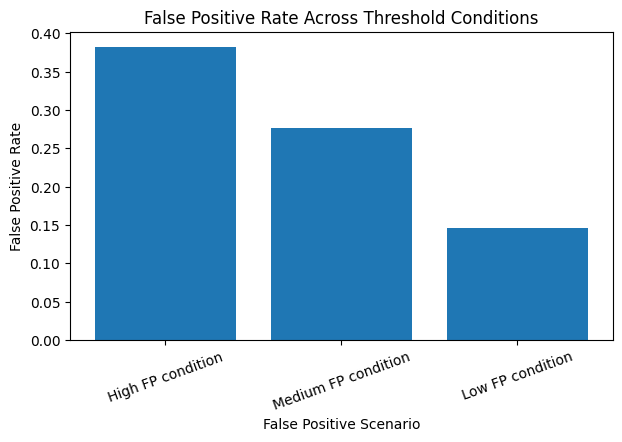

In [10]:
# Visualise false-positive rates across conditions
plt.figure(figsize=(7, 4))
plt.bar(threshold_summary["Model"], threshold_summary["False Positive Rate"])
plt.ylabel("False Positive Rate")
plt.xlabel("False Positive Scenario")
plt.title("False Positive Rate Across Threshold Conditions")
plt.xticks(rotation=20)
plt.show()


In [11]:
# Create sample alert sets for developer survey
# These can be used in your web interface.

alert_df = X_test.copy()
alert_df["true_label"] = y_test.values
alert_df["attack_probability"] = rf_probs

for condition, threshold in thresholds.items():
    alert_df[condition] = (rf_probs >= threshold).astype(int)

# Select useful columns for display
display_cols = []
for col in ["proto", "service", "state", "dur", "sbytes", "dbytes", "rate"]:
    if col in alert_df.columns:
        display_cols.append(col)

survey_alerts = alert_df[display_cols + ["true_label", "attack_probability"] + list(thresholds.keys())].copy()

# Save alert examples
survey_alerts.sample(100, random_state=42).to_csv("survey_alert_examples.csv", index=False)

survey_alerts.head()


,proto,service,state,dur,sbytes,dbytes,rate,true_label,attack_probability,High FP condition,Medium FP condition,Low FP condition
0,udp,-,INT,0.000011,496,0,90909.0902,0,0.701777,1,1,1
1,udp,-,INT,0.000008,1762,0,125000.0003,0,0.890000,1,1,1
2,udp,-,INT,0.000005,1068,0,200000.0051,0,0.641518,1,1,0
3,udp,-,INT,0.000006,900,0,166666.6608,0,0.863194,1,1,1
4,udp,-,INT,0.000010,2126,0,100000.0025,0,0.710000,1,1,1


## How to use the output

Use `threshold_summary` for the thesis technical evaluation.

Use `survey_alert_examples.csv` to build the web interface or survey screenshots.

For the developer study:
- Low FP condition = stricter threshold
- Medium FP condition = standard threshold
- High FP condition = sensitive threshold

Each participant can evaluate all three scenarios if you use a within-subjects design.
